# Datenvorverarbeitung

In diesem Notebook wird der validierte Datensatz weiterverarbeitet.  
Der Schwerpunkt liegt auf **Feature Engineering**, **Encoding** und einer einfachen
Preprocessing-Pipeline, die denselben Ablauf später reproduzierbar macht.

Der ausführbare Code für die Pipeline liegt im Projekt unter `src/loan_mlops/features.py`.  
Im Notebook wird dieser Code verwendet und an den Zwischenergebnissen erklärt.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import unittest
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from loan_mlops.features import PreprocessingPipeline, add_engineered_features

plt.style.use("seaborn-v0_8-darkgrid")


## 1. Validierte Daten laden


In [2]:
df = pd.read_csv("../data/processed/loan_data_validated.csv")
print(f"Datensatz geladen: {df.shape}")
df.head()


Datensatz geladen: (9578, 14)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## 2. Feature Engineering

Hier werden zusätzliche Merkmale erzeugt, die verschiedene Seiten des Kreditrisikos besser abbilden.


In [3]:
categorical_features = ["purpose"]

numerical_features = [
    "int.rate",
    "installment",
    "log.annual.inc",
    "dti",
    "fico",
    "days.with.cr.line",
    "revol.bal",
    "revol.util",
    "inq.last.6mths",
    "delinq.2yrs",
    "pub.rec",
]

binary_features = ["credit.policy"]
target = "not.fully.paid"


### 2.1 Neue Features erzeugen

Die neuen Features werden nicht von Hand in mehreren Zellen nachgebaut,
sondern mit derselben Funktion erzeugt, die auch in der produktiven Pipeline benutzt wird.


In [4]:
df_features = add_engineered_features(df)

new_features = [
    "debt_burden_ratio",
    "dti_to_fico",
    "int_rate_to_fico",
    "revol_bal_to_inc",
]

df_features[new_features + ["not.fully.paid"]].head()


,debt_burden_ratio,dti_to_fico,int_rate_to_fico,revol_bal_to_inc,not.fully.paid
0,0.190010,0.026431,0.000161,0.339459,0
1,0.050173,0.020212,0.000151,0.517277,0
2,0.133331,0.017053,0.000199,0.109719,0
3,0.015470,0.011376,0.000142,0.396082,0
4,0.019068,0.022444,0.000214,0.058663,0


In [5]:
df_features.groupby("not.fully.paid")[new_features].mean()


,debt_burden_ratio,dti_to_fico,int_rate_to_fico,revol_bal_to_inc
not.fully.paid,,,,
0,0.071290,0.017687,0.000171,0.228733
1,0.081478,0.019036,0.000191,0.270128


Die Mittelwerte zeigen, dass die erzeugten Features zwischen Krediten mit und ohne Zahlungsausfall unterscheiden.
Vor allem `int_rate_to_fico`, `revol_bal_to_inc` und `debt_burden_ratio` sind für das Risiko interessant.


In [6]:
df_features[new_features + ["not.fully.paid"]].corr()["not.fully.paid"].sort_values(ascending=False)


not.fully.paid       1.000000
int_rate_to_fico     0.164554
debt_burden_ratio    0.057909
revol_bal_to_inc     0.056292
dti_to_fico          0.049672
Name: not.fully.paid, dtype: float64

Die Korrelationen sind nicht extrem hoch, aber das ist bei Finanzdaten normal.
Wichtiger ist hier, dass die Features zusätzliche Struktur in die Daten bringen und fachlich sinnvoll begründet sind.


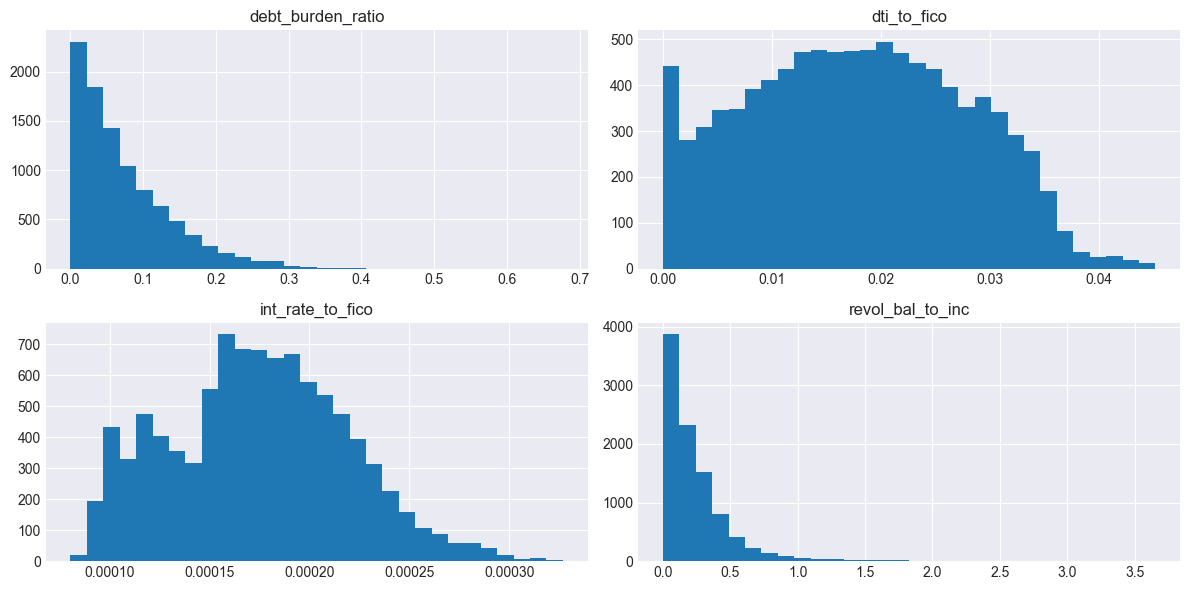

In [7]:
df_features[new_features].hist(figsize=(12, 6), bins=30)
plt.tight_layout()
plt.show()


Einige Verteilungen sind rechtsschief. Das ist bei Finanzdaten nicht ungewöhnlich,
weil viele Fälle im unteren Bereich liegen und nur wenige Fälle sehr hohe Werte annehmen.


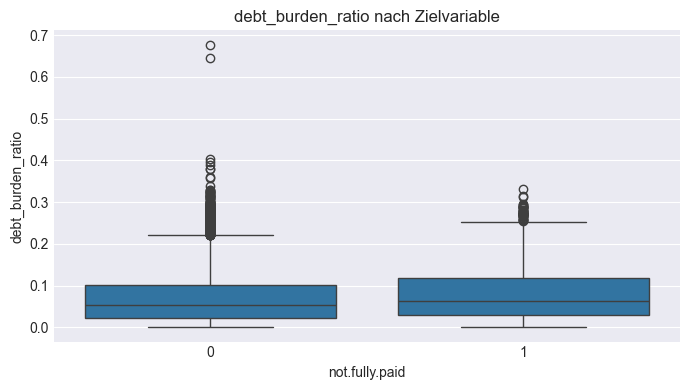

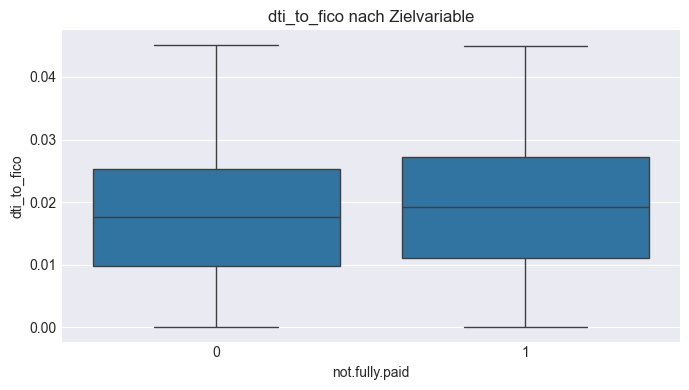

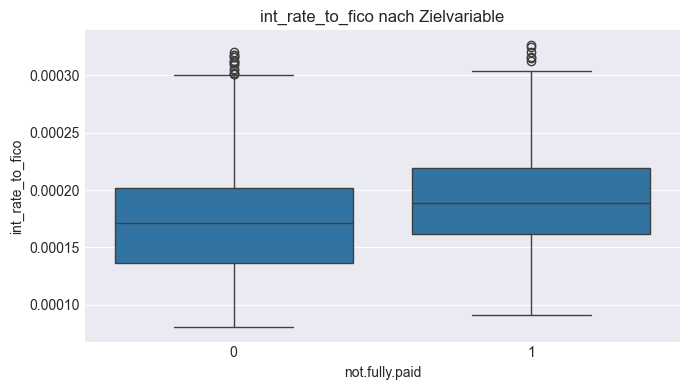

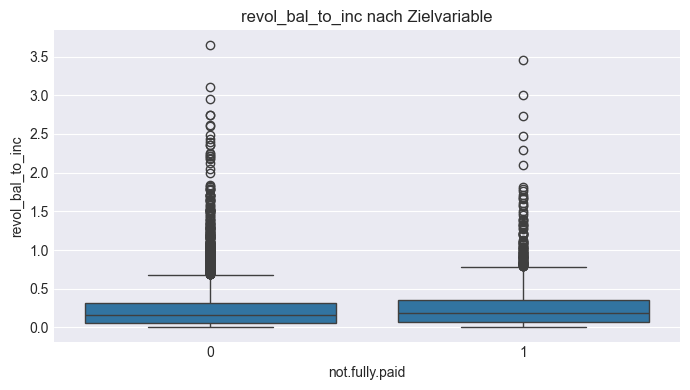

In [8]:
for feature in new_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="not.fully.paid", y=feature, data=df_features)
    plt.title(f"{feature} nach Zielvariable")
    plt.tight_layout()
    plt.show()


Die Boxplots zeigen, dass die neue Feature-Gruppe Unterschiede zwischen den Klassen sichtbar macht.
Damit lohnt es sich, diese Merkmale im Trainingsdatensatz beizubehalten.


## 3. Preprocessing-Pipeline anwenden

Die Pipeline übernimmt drei Dinge in einer festen Reihenfolge:

1. Daten bereinigen  
2. Features erzeugen  
3. Kategoriale Variablen encoden  

Am Ende wird der Datensatz gespeichert.


In [9]:
pipeline = PreprocessingPipeline()
df_preprocessed = pipeline.transform(df)
print("Vorverarbeiteter Datensatz:", df_preprocessed.shape)


Vorverarbeiteter Datensatz: (9578, 23)


In [10]:
df_preprocessed.head()


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,...,dti_to_fico,int_rate_to_fico,revol_bal_to_inc,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,not.fully.paid
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,...,0.026431,0.000161,0.339459,0,1,0,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,...,0.020212,0.000151,0.517277,1,0,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,...,0.017053,0.000199,0.109719,0,1,0,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,...,0.011376,0.000142,0.396082,0,1,0,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,...,0.022444,0.000214,0.058663,1,0,0,0,0,0,0


## 4. Kurzer Blick auf das Ergebnis

Jetzt sollten die Textwerte aus `purpose` in Dummy-Spalten umgewandelt sein,
und die vier neuen Features sollten ebenfalls im Datensatz auftauchen.


In [11]:
wichtige_spalten = [
    "debt_burden_ratio",
    "dti_to_fico",
    "int_rate_to_fico",
    "revol_bal_to_inc",
    "purpose_credit_card",
    "purpose_debt_consolidation",
    "purpose_small_business",
]
df_preprocessed[wichtige_spalten].head()


,debt_burden_ratio,dti_to_fico,int_rate_to_fico,revol_bal_to_inc,purpose_credit_card,purpose_debt_consolidation,purpose_small_business
0,0.190010,0.026431,0.000161,0.339459,0,1,0
1,0.050173,0.020212,0.000151,0.517277,1,0,0
2,0.133331,0.017053,0.000199,0.109719,0,1,0
3,0.015470,0.011376,0.000142,0.396082,0,1,0
4,0.019068,0.022444,0.000214,0.058663,1,0,0


## 5. Einfacher Test der Pipeline

Der Test ist absichtlich klein gehalten.  
Er prüft nur, ob die zentralen Feature-Spalten tatsächlich erzeugt werden.


In [12]:
class TestPreprocessingPipeline(unittest.TestCase):

    def setUp(self):
        self.pipeline = PreprocessingPipeline(output_path=None)

    def test_engineer_features(self):
        sample_df = pd.DataFrame({
            "credit.policy": [1, 1],
            "purpose": ["credit_card", "debt_consolidation"],
            "int.rate": [0.10, 0.15],
            "installment": [100, 200],
            "log.annual.inc": [10, 11],
            "dti": [5, 10],
            "fico": [700, 650],
            "days.with.cr.line": [1000, 2000],
            "revol.bal": [5000, 6000],
            "revol.util": [30, 40],
            "inq.last.6mths": [1, 2],
            "delinq.2yrs": [0, 1],
            "pub.rec": [0, 0],
            "not.fully.paid": [0, 1],
        })

        result = self.pipeline.transform(sample_df)

        self.assertIn("debt_burden_ratio", result.columns)
        self.assertIn("dti_to_fico", result.columns)
        self.assertIn("int_rate_to_fico", result.columns)
        self.assertIn("revol_bal_to_inc", result.columns)

unittest.main(argv=[""], exit=False)


.
----------------------------------------------------------------------
Ran 1 test in 0.008s

OK
